## **Ultralytics Modeling**
YOLOv8 training, validation, and visualization for the Kaggle traffic sign dataset.

In [1]:
import os

try:
    from google.colab import userdata
except Exception:
    userdata = None

In [2]:
if userdata is not None:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
else:
    os.environ['KAGGLE_USERNAME'] = "prateekpandaa"
    os.environ['KAGGLE_KEY'] = "KGAT_9ccc2dae93b58ac4790459fd5014a6e9"

In [3]:
!pip install -q kaggle

# Download the dataset
import zipfile
from pathlib import Path

extract_dir = Path("cardetection_dataset")
zip_path = Path("cardetection.zip")

# Skip download if dataset already exists
if not extract_dir.exists():
    !kaggle datasets download -d pkdarabi/cardetection
    
    # Unzip the downloaded dataset
    if zip_path.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f"Dataset extracted to {extract_dir}")
else:
    print(f"Dataset already exists at {extract_dir}")

Dataset already exists at cardetection_dataset


In [4]:
!pip install -q ultralytics

import os
import glob
from IPython.display import Image, display
from ultralytics import YOLO

In [5]:
# Initialize YOLOv8n
model_ultralytics = YOLO("yolov8n.pt")

yaml_path = "cardetection_dataset/car/data.yaml"

results = model_ultralytics.train(
    data=yaml_path,
    epochs=5,
    imgsz=416,
    batch=16,
    device=0,
    project="yolov8_traffic_signs",
    name="train_run",
)

Ultralytics 8.4.46  Python-3.12.10 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cardetection_dataset/car/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_run-9, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

In [6]:
metrics = model_ultralytics.val(
    split="test",
    project="yolov8_traffic_signs",
    name="val_run",
    plots=True,
)

print("Quantitative Metrics (Test Set):")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.46  Python-3.12.10 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 5.91.4 MB/s, size: 20.8 KB)
val: Scanning C:\Users\Panda\Downloads\171\traffic-sign-detection\cardetection_dataset\car\test\labels... 638 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 1.1Kit/s 0.6s<0.1s
val: New cache created: C:\Users\Panda\Downloads\171\traffic-sign-detection\cardetection_dataset\car\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 18.8it/s 2.1s0.1s
                   all        638        770      0.787      0.578      0.692      0.587
           Green Light         77        110      0.764      0.441      0.624      0.367
             Red Light         71         94      0.641      0.489      0.531      0.301
        Speed Limit 10      

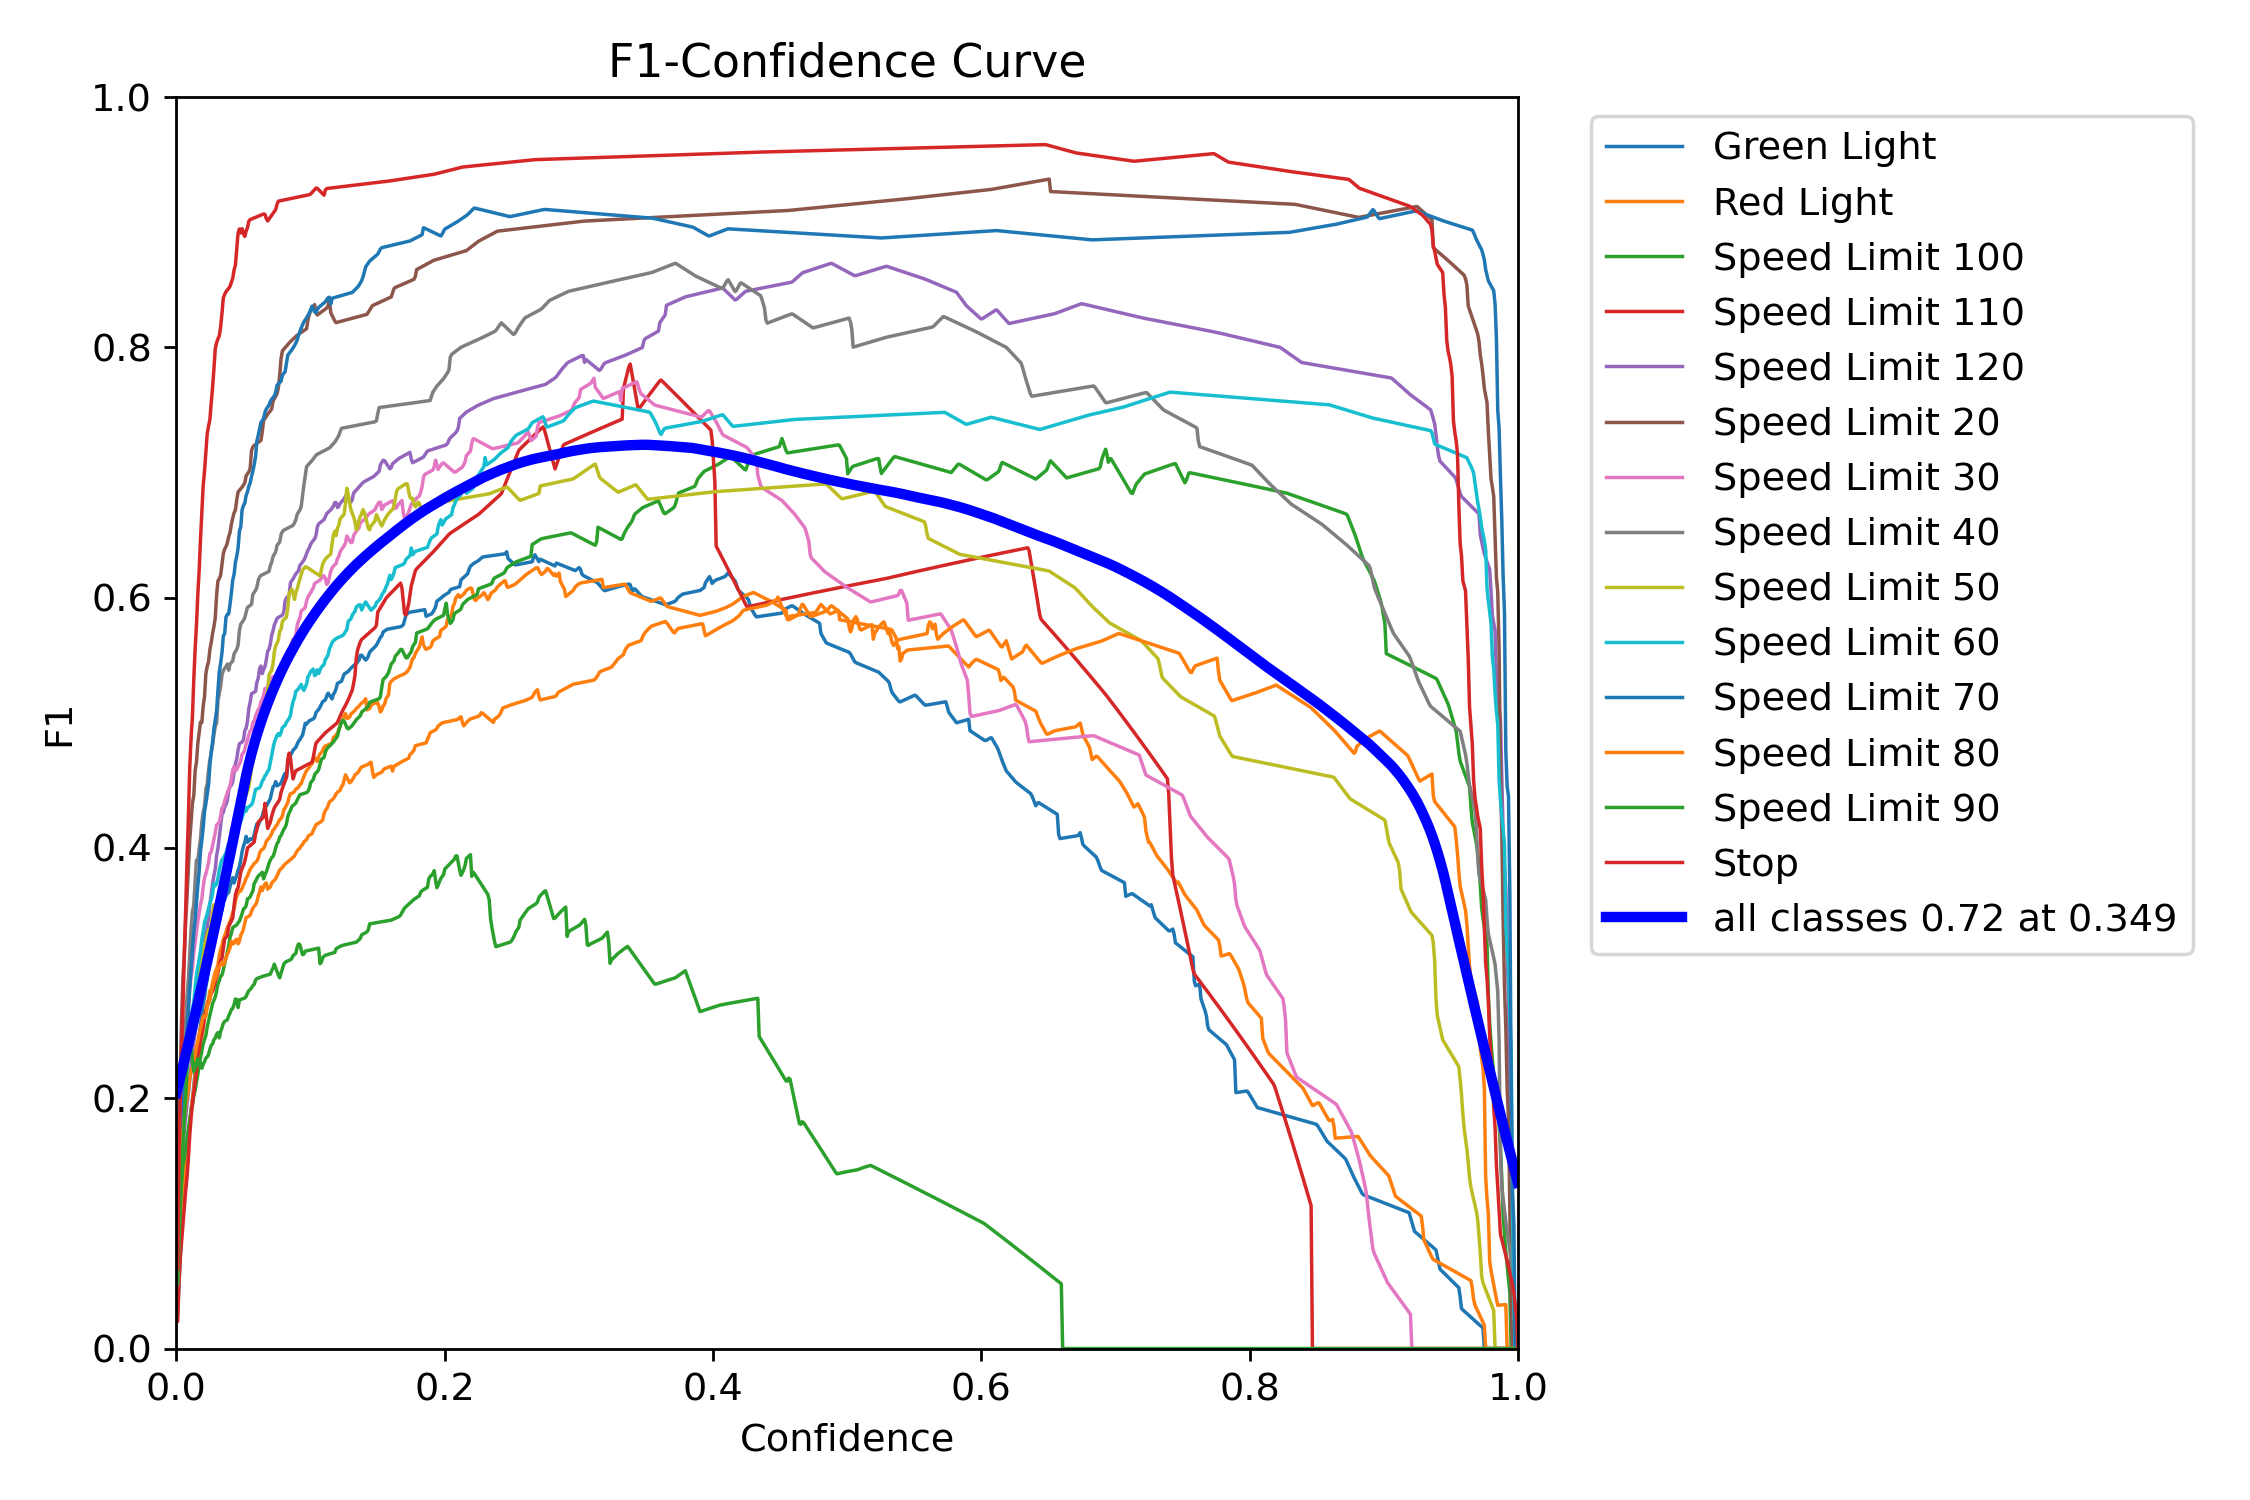

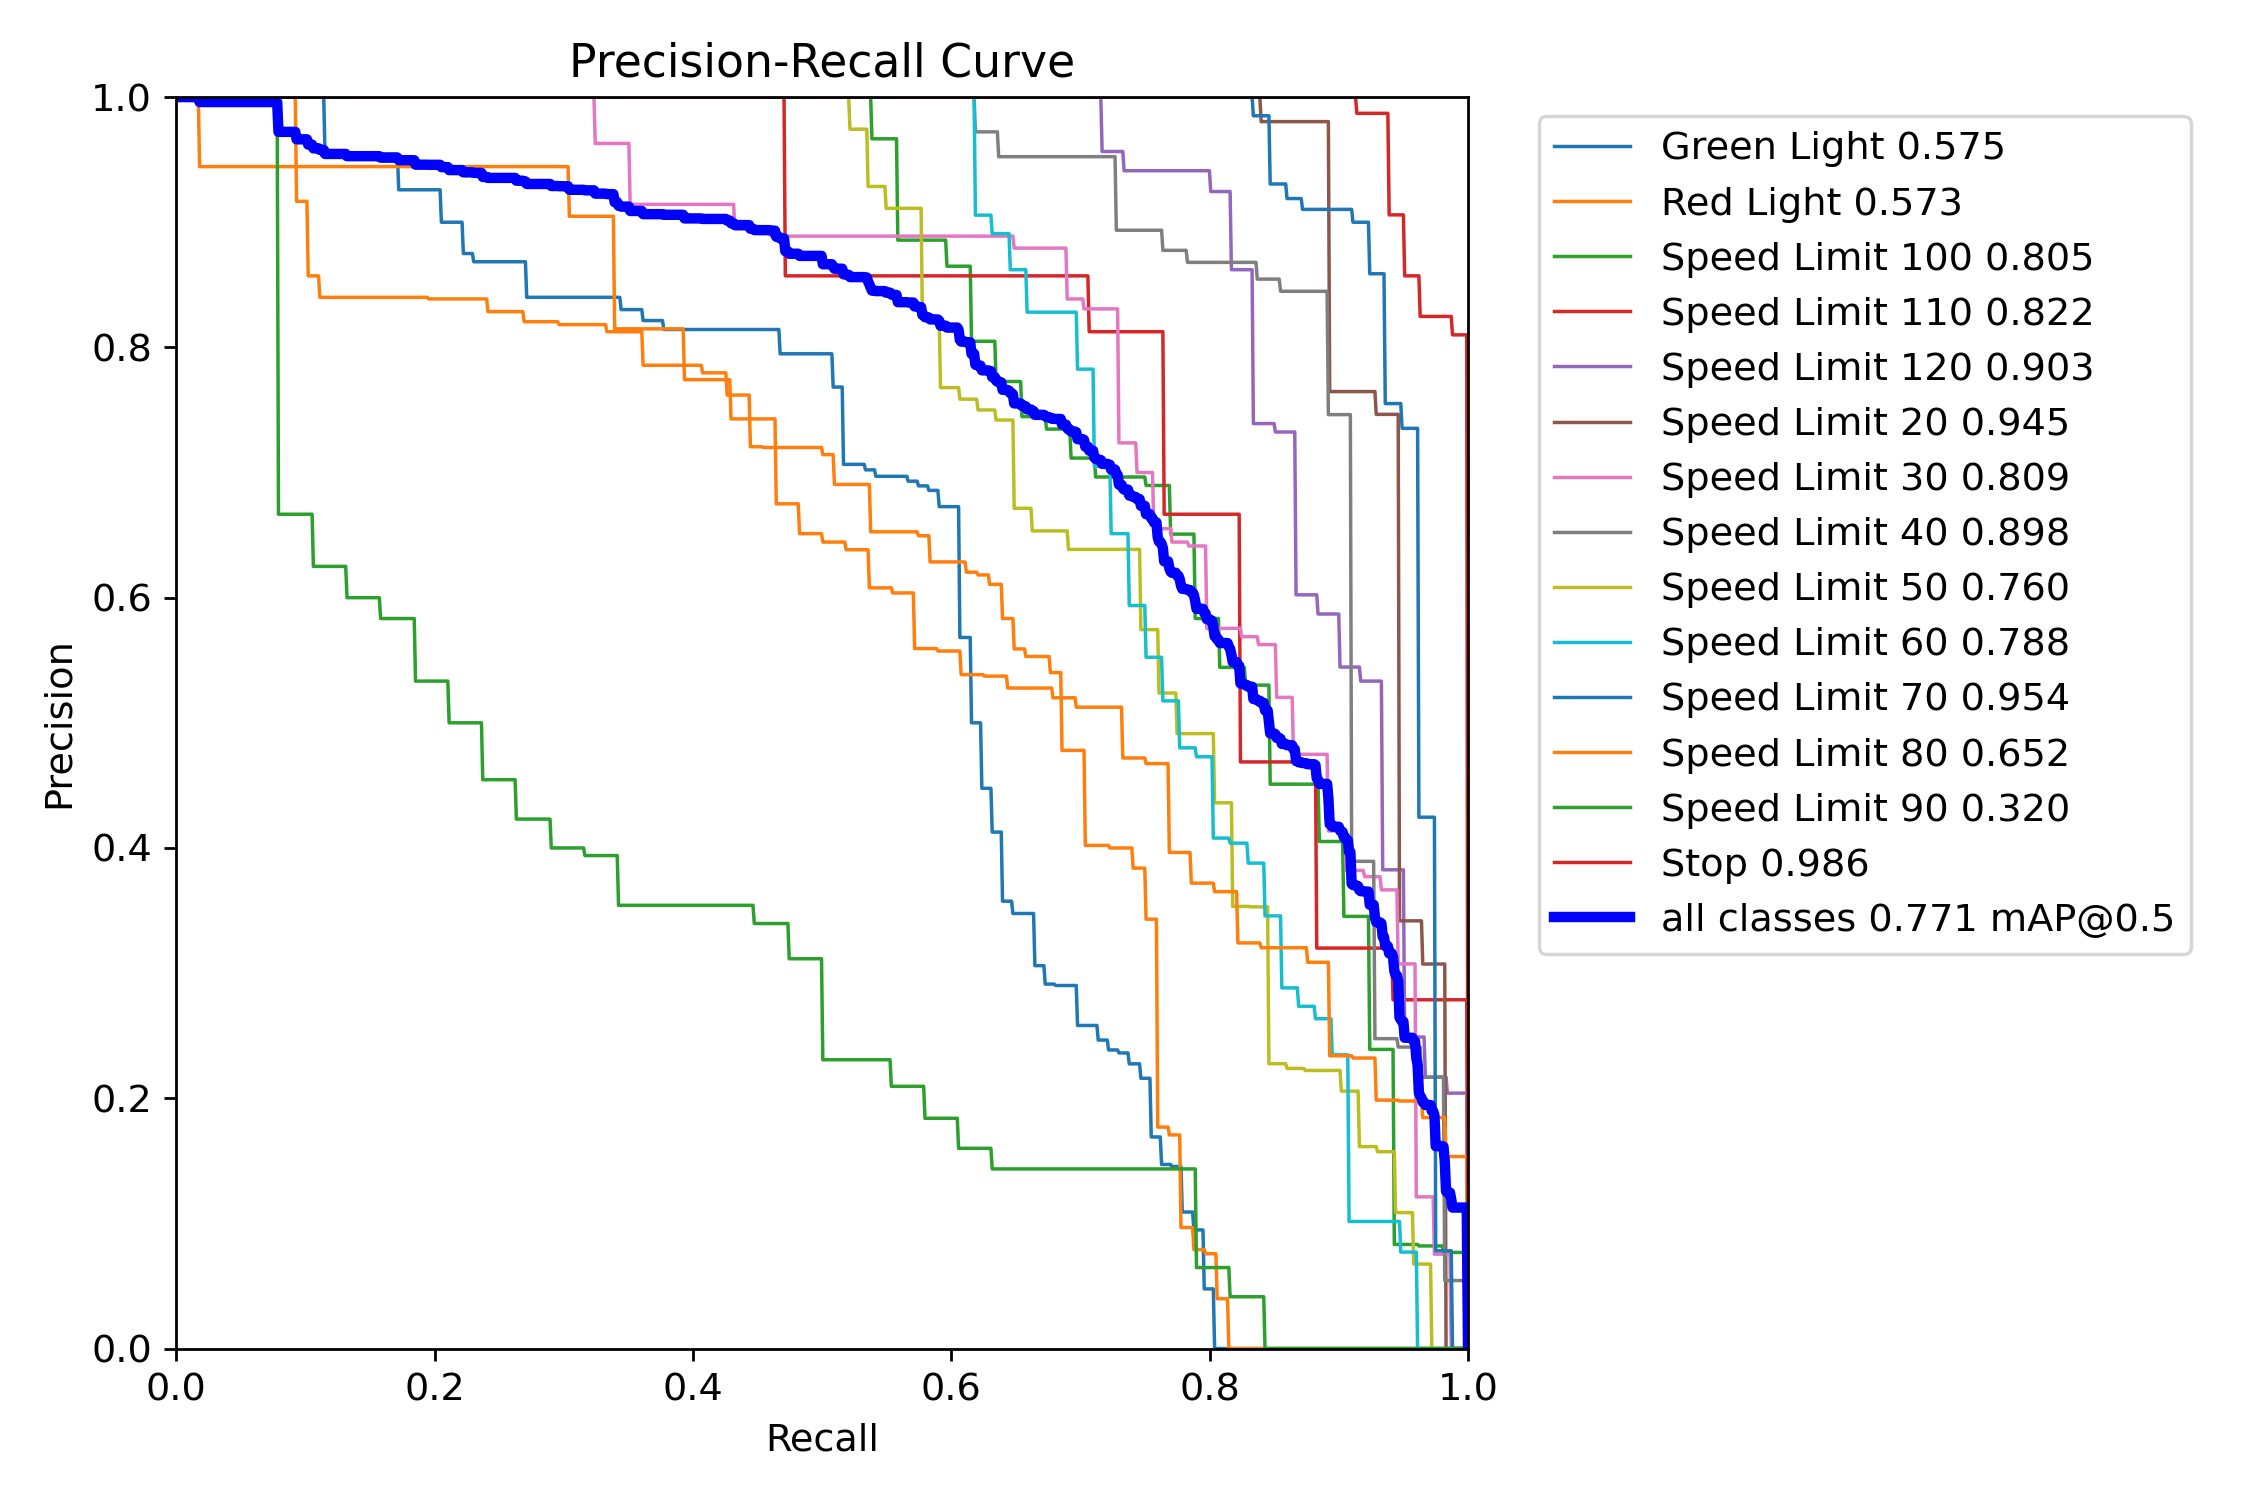

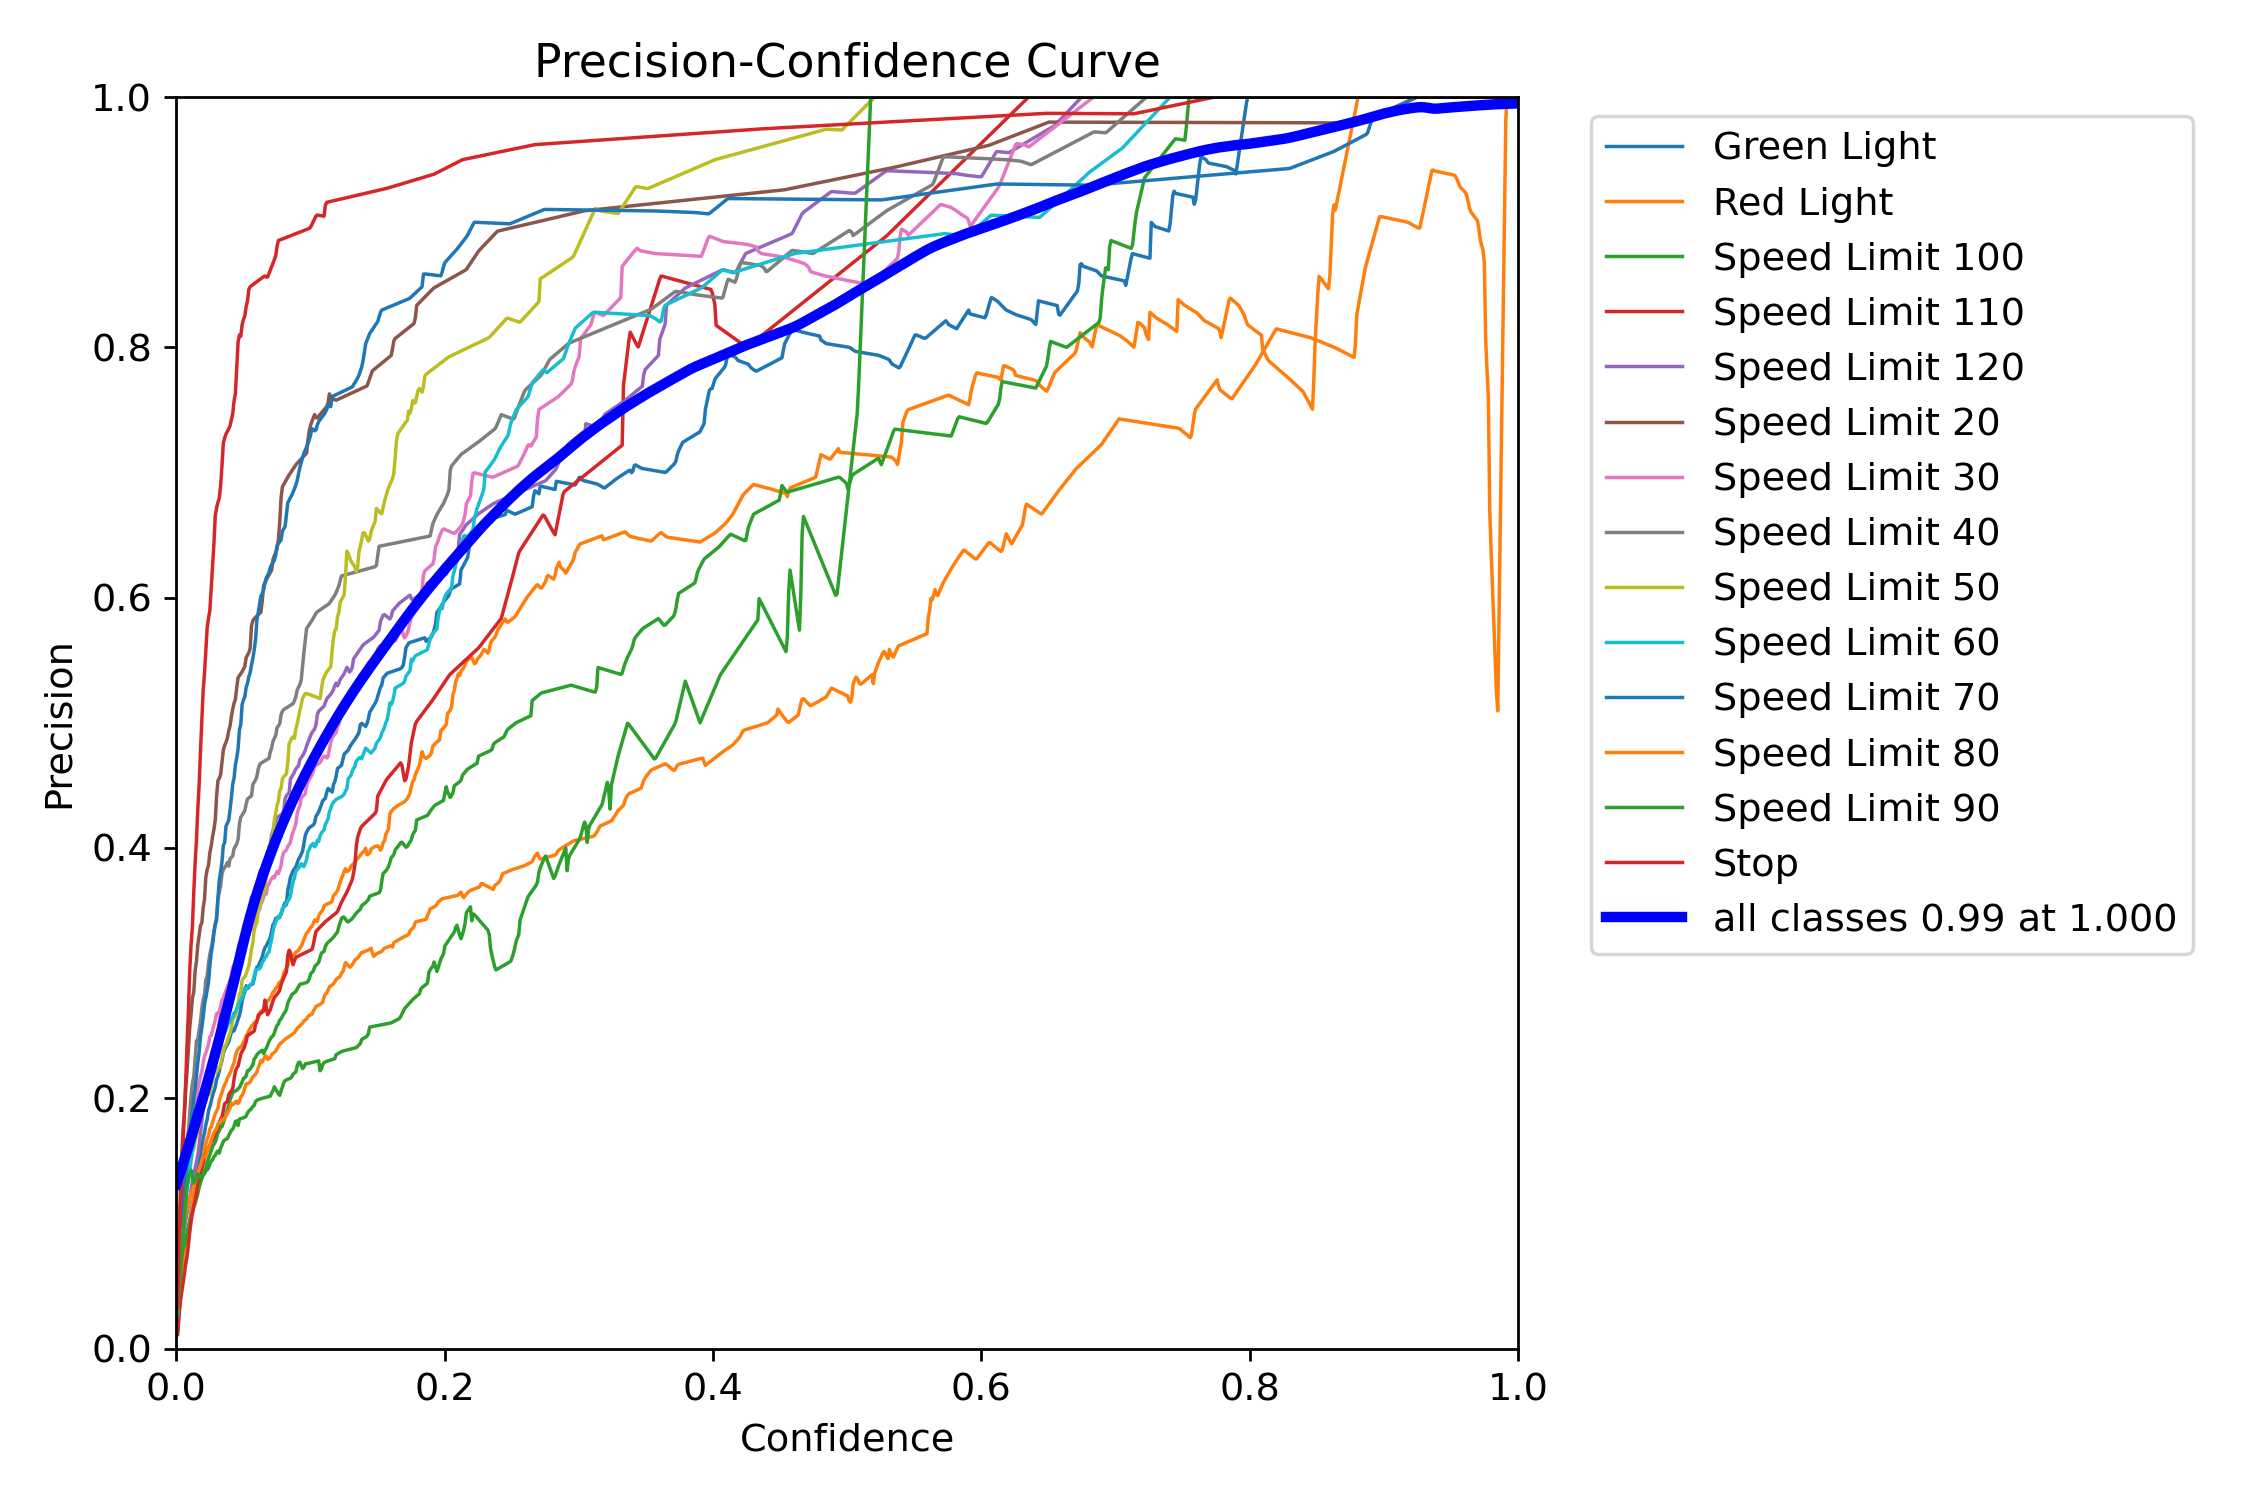

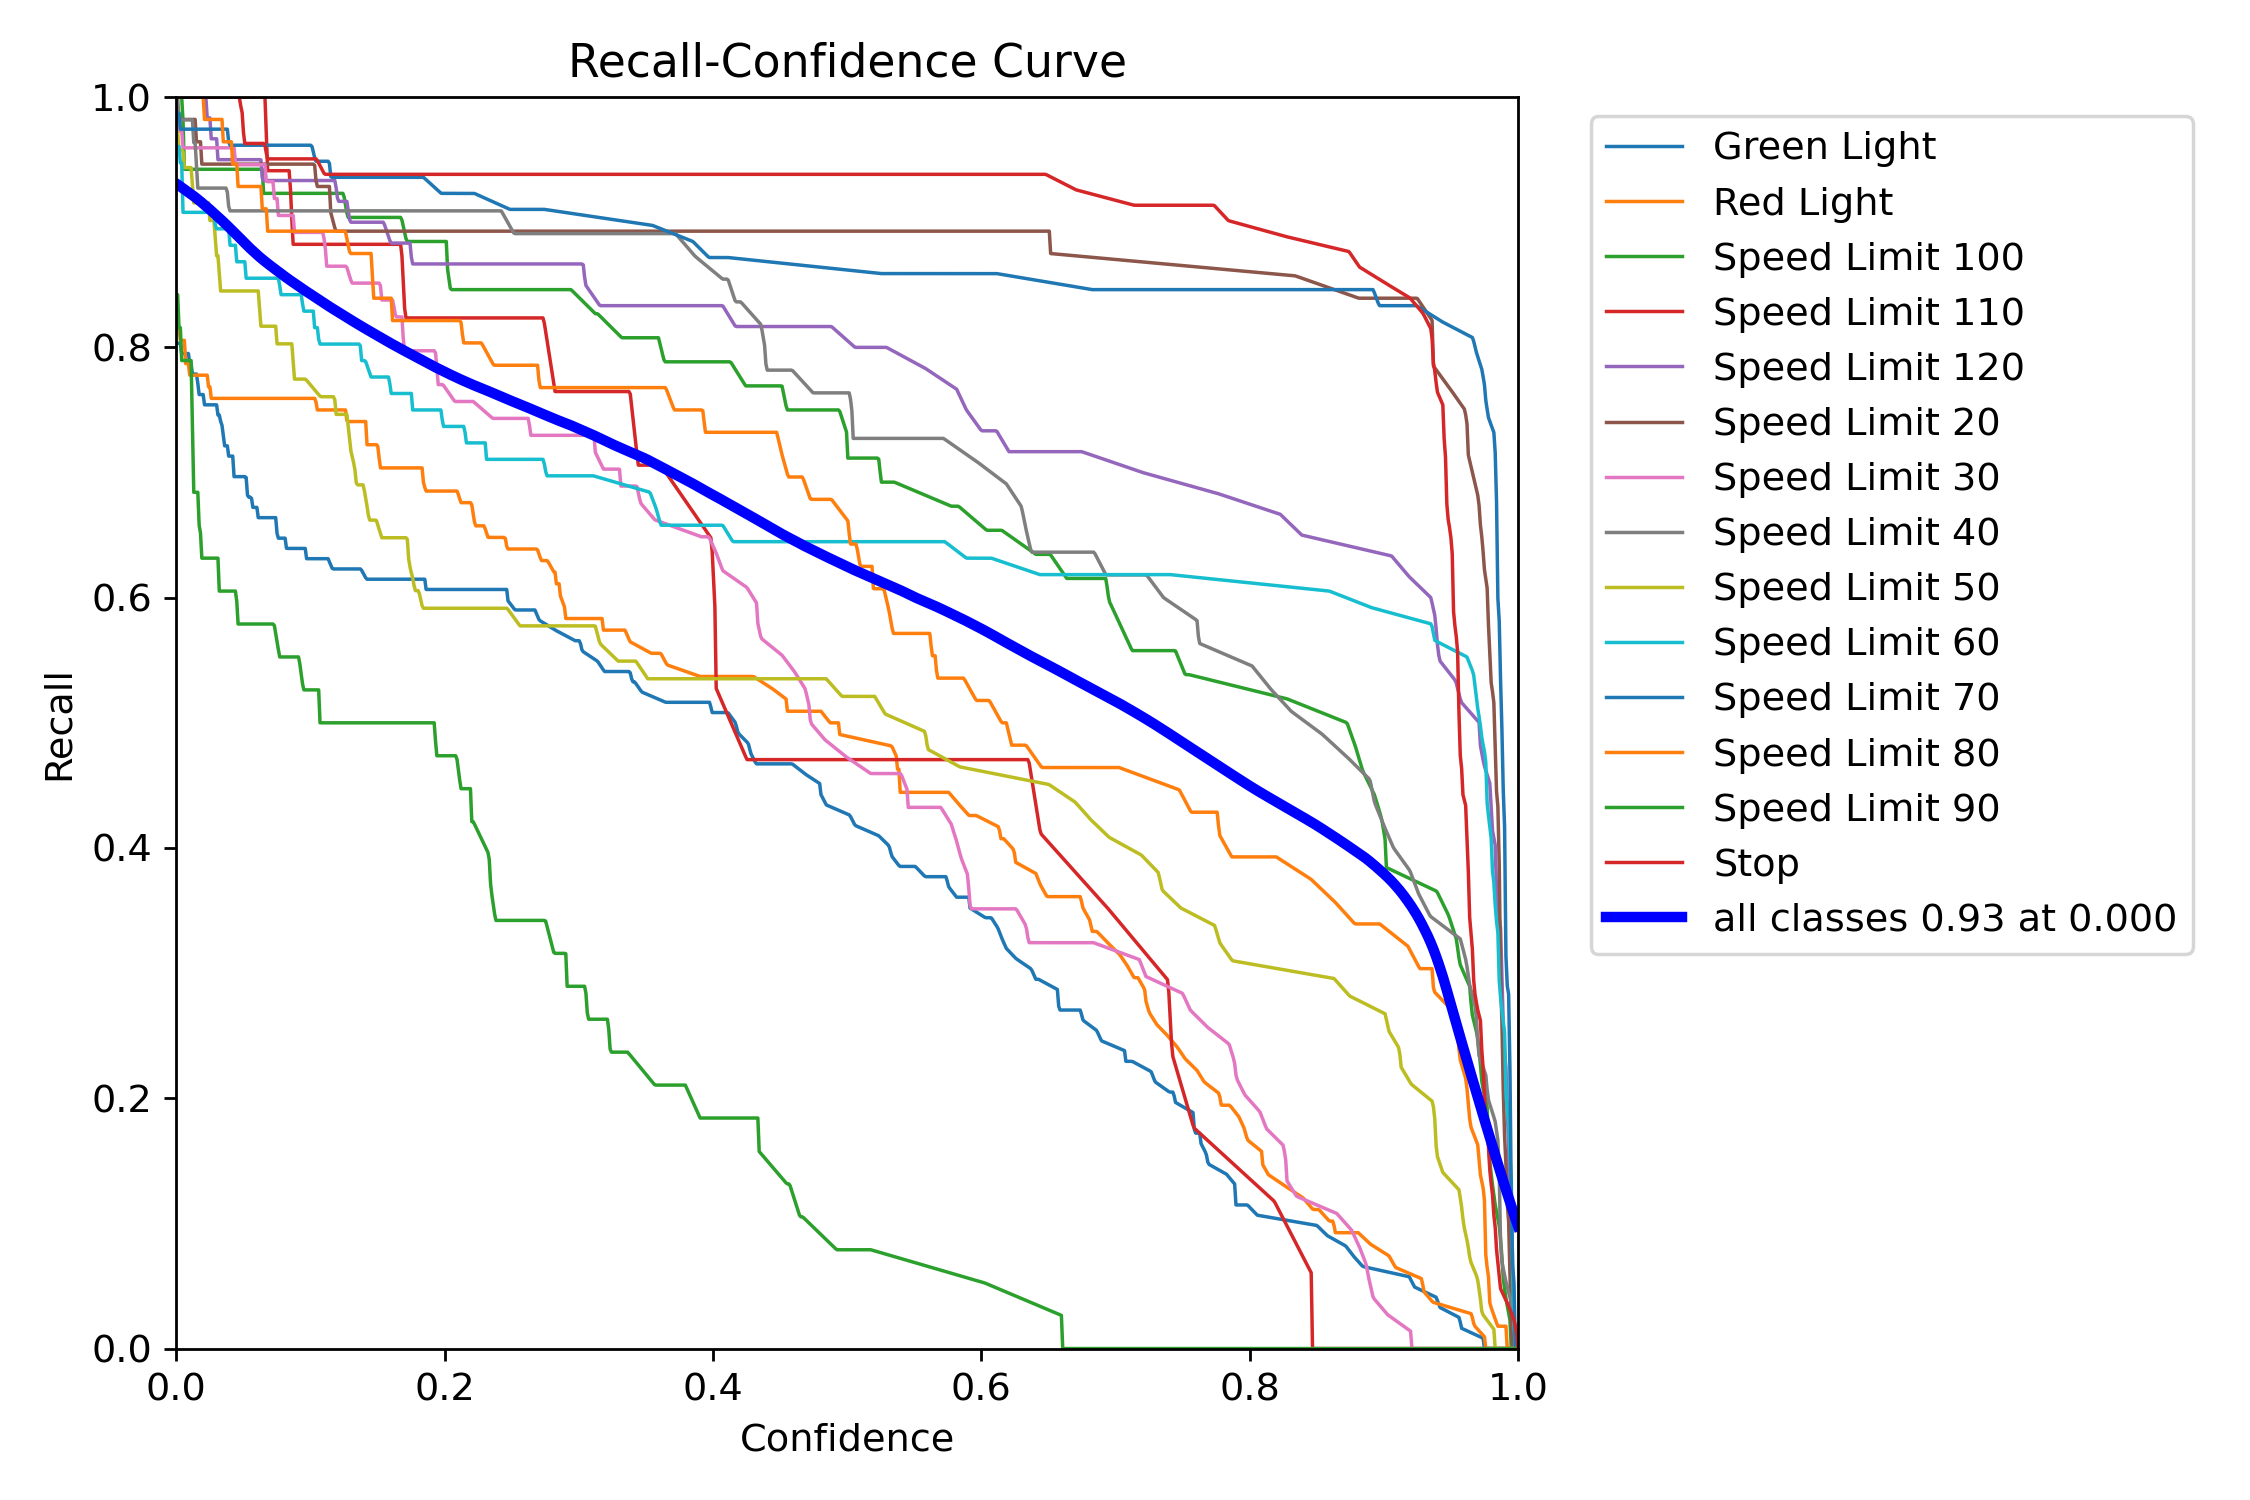

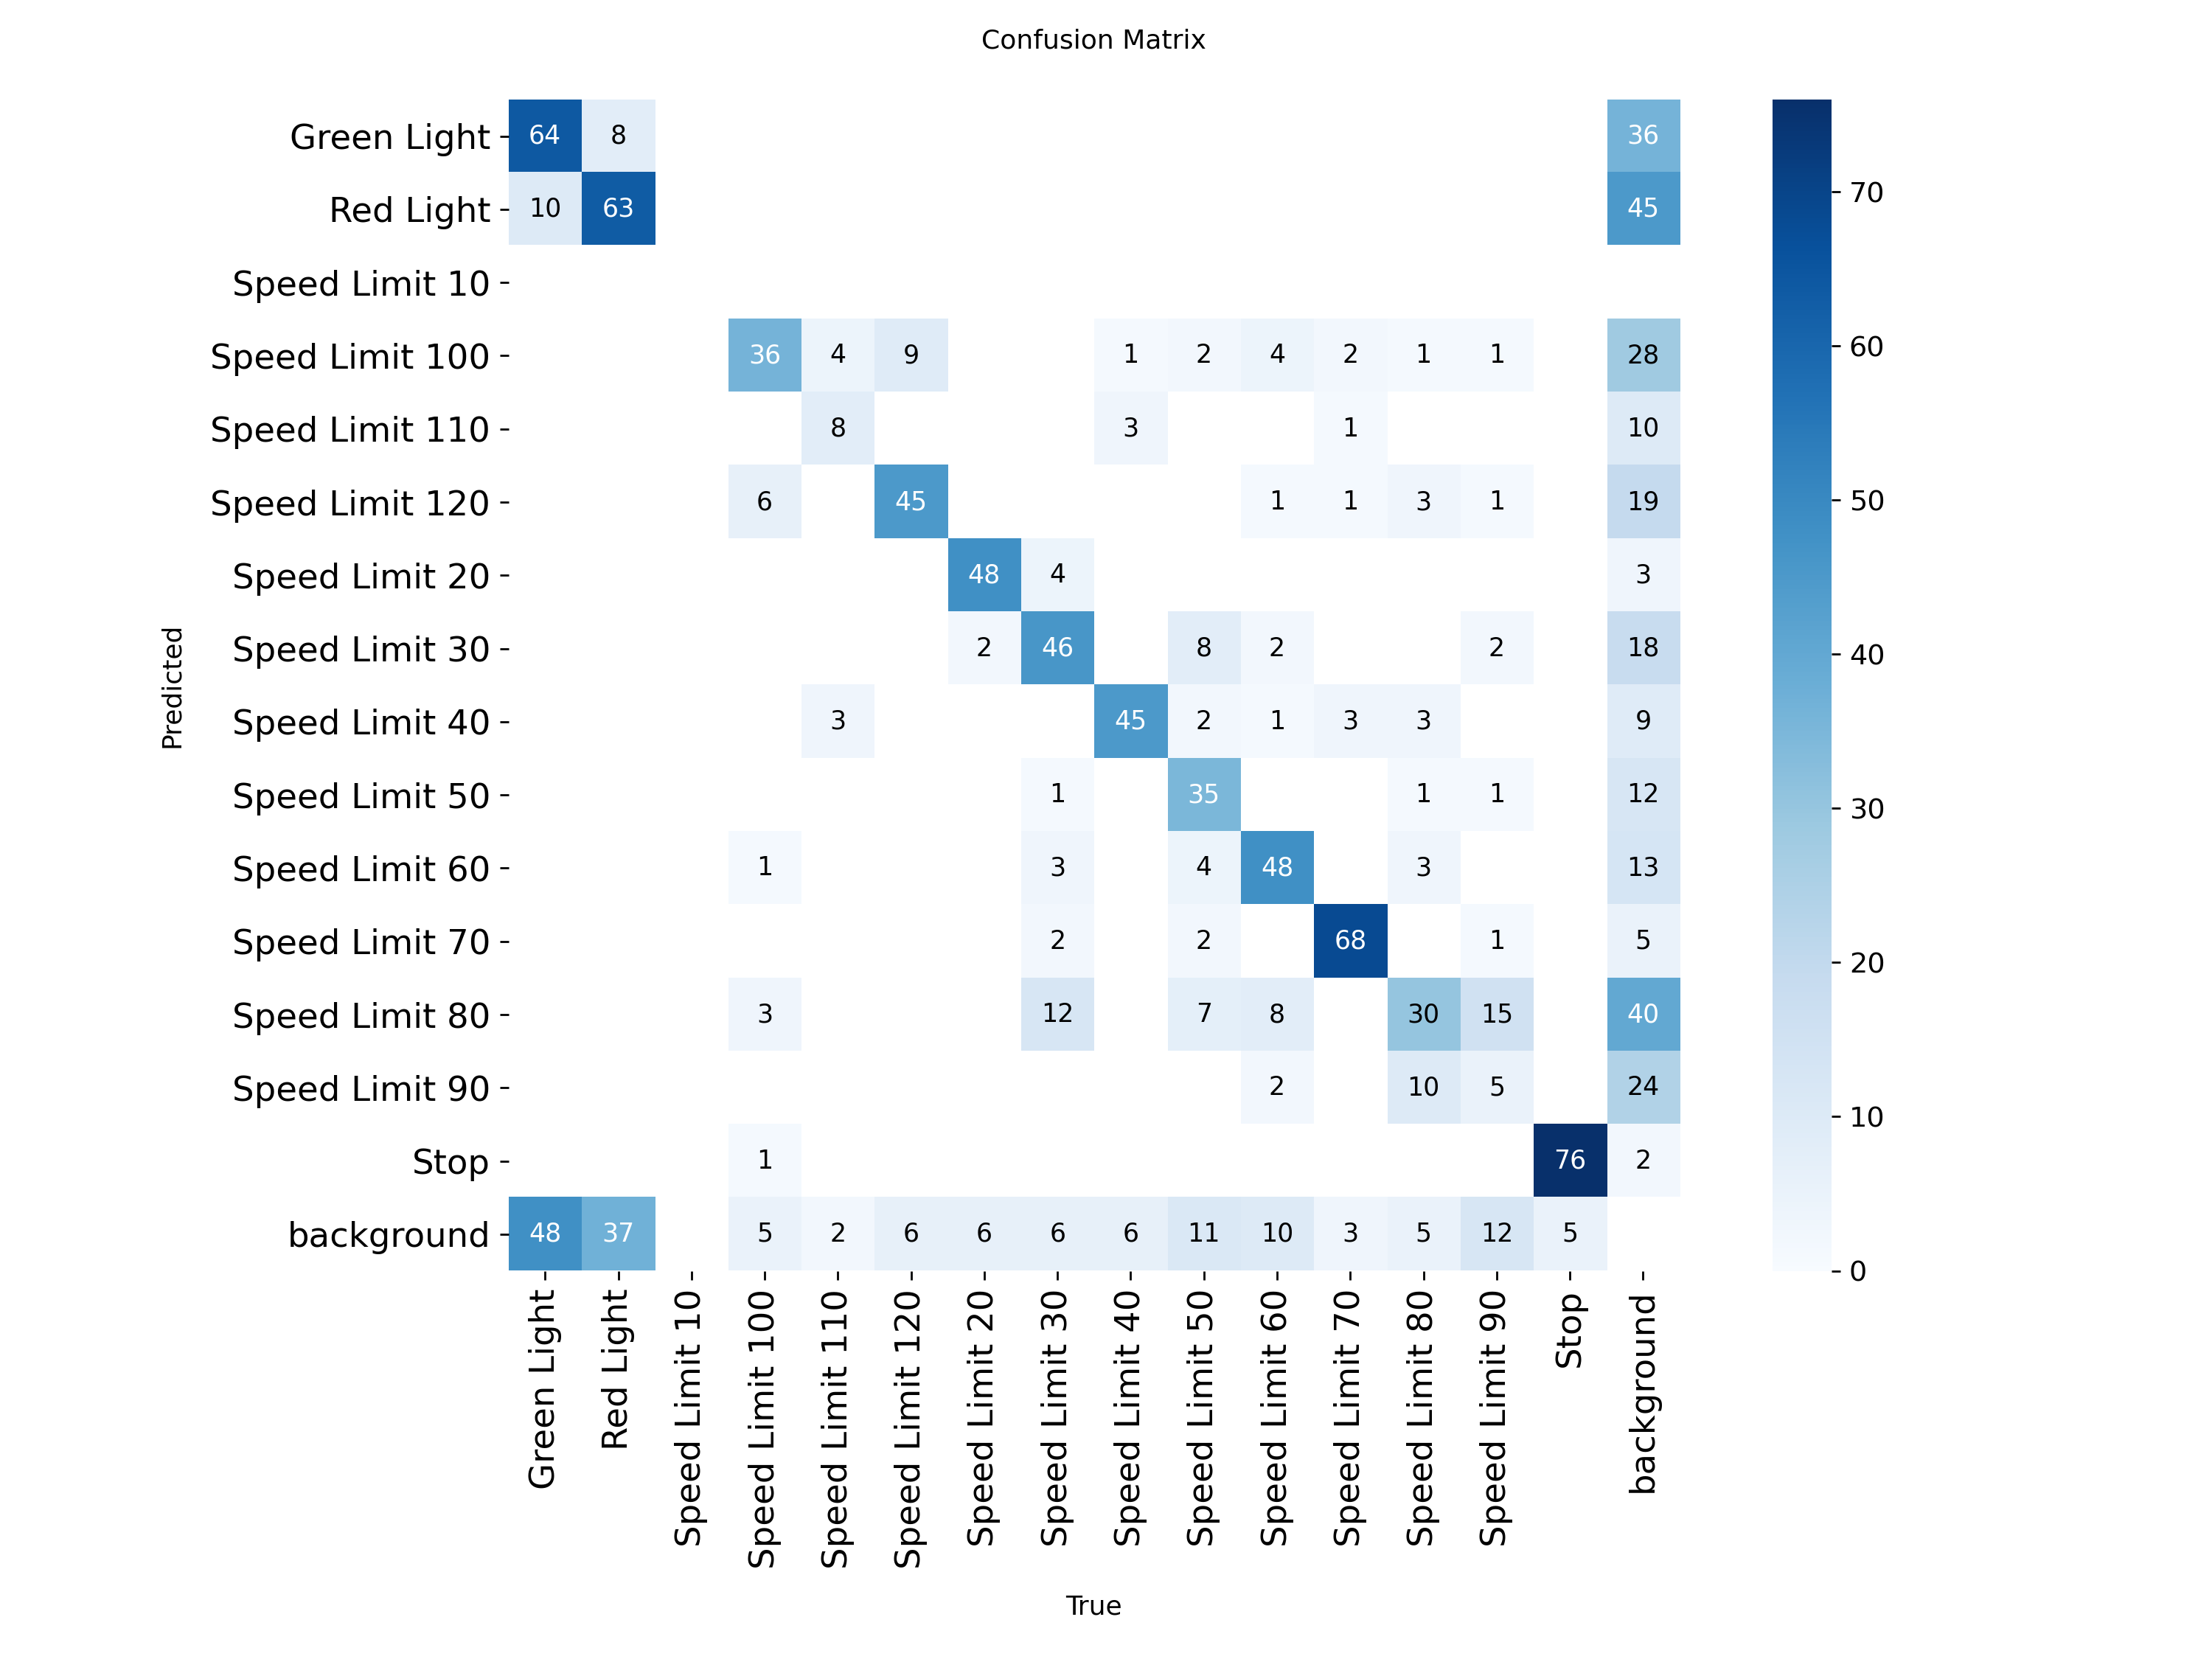

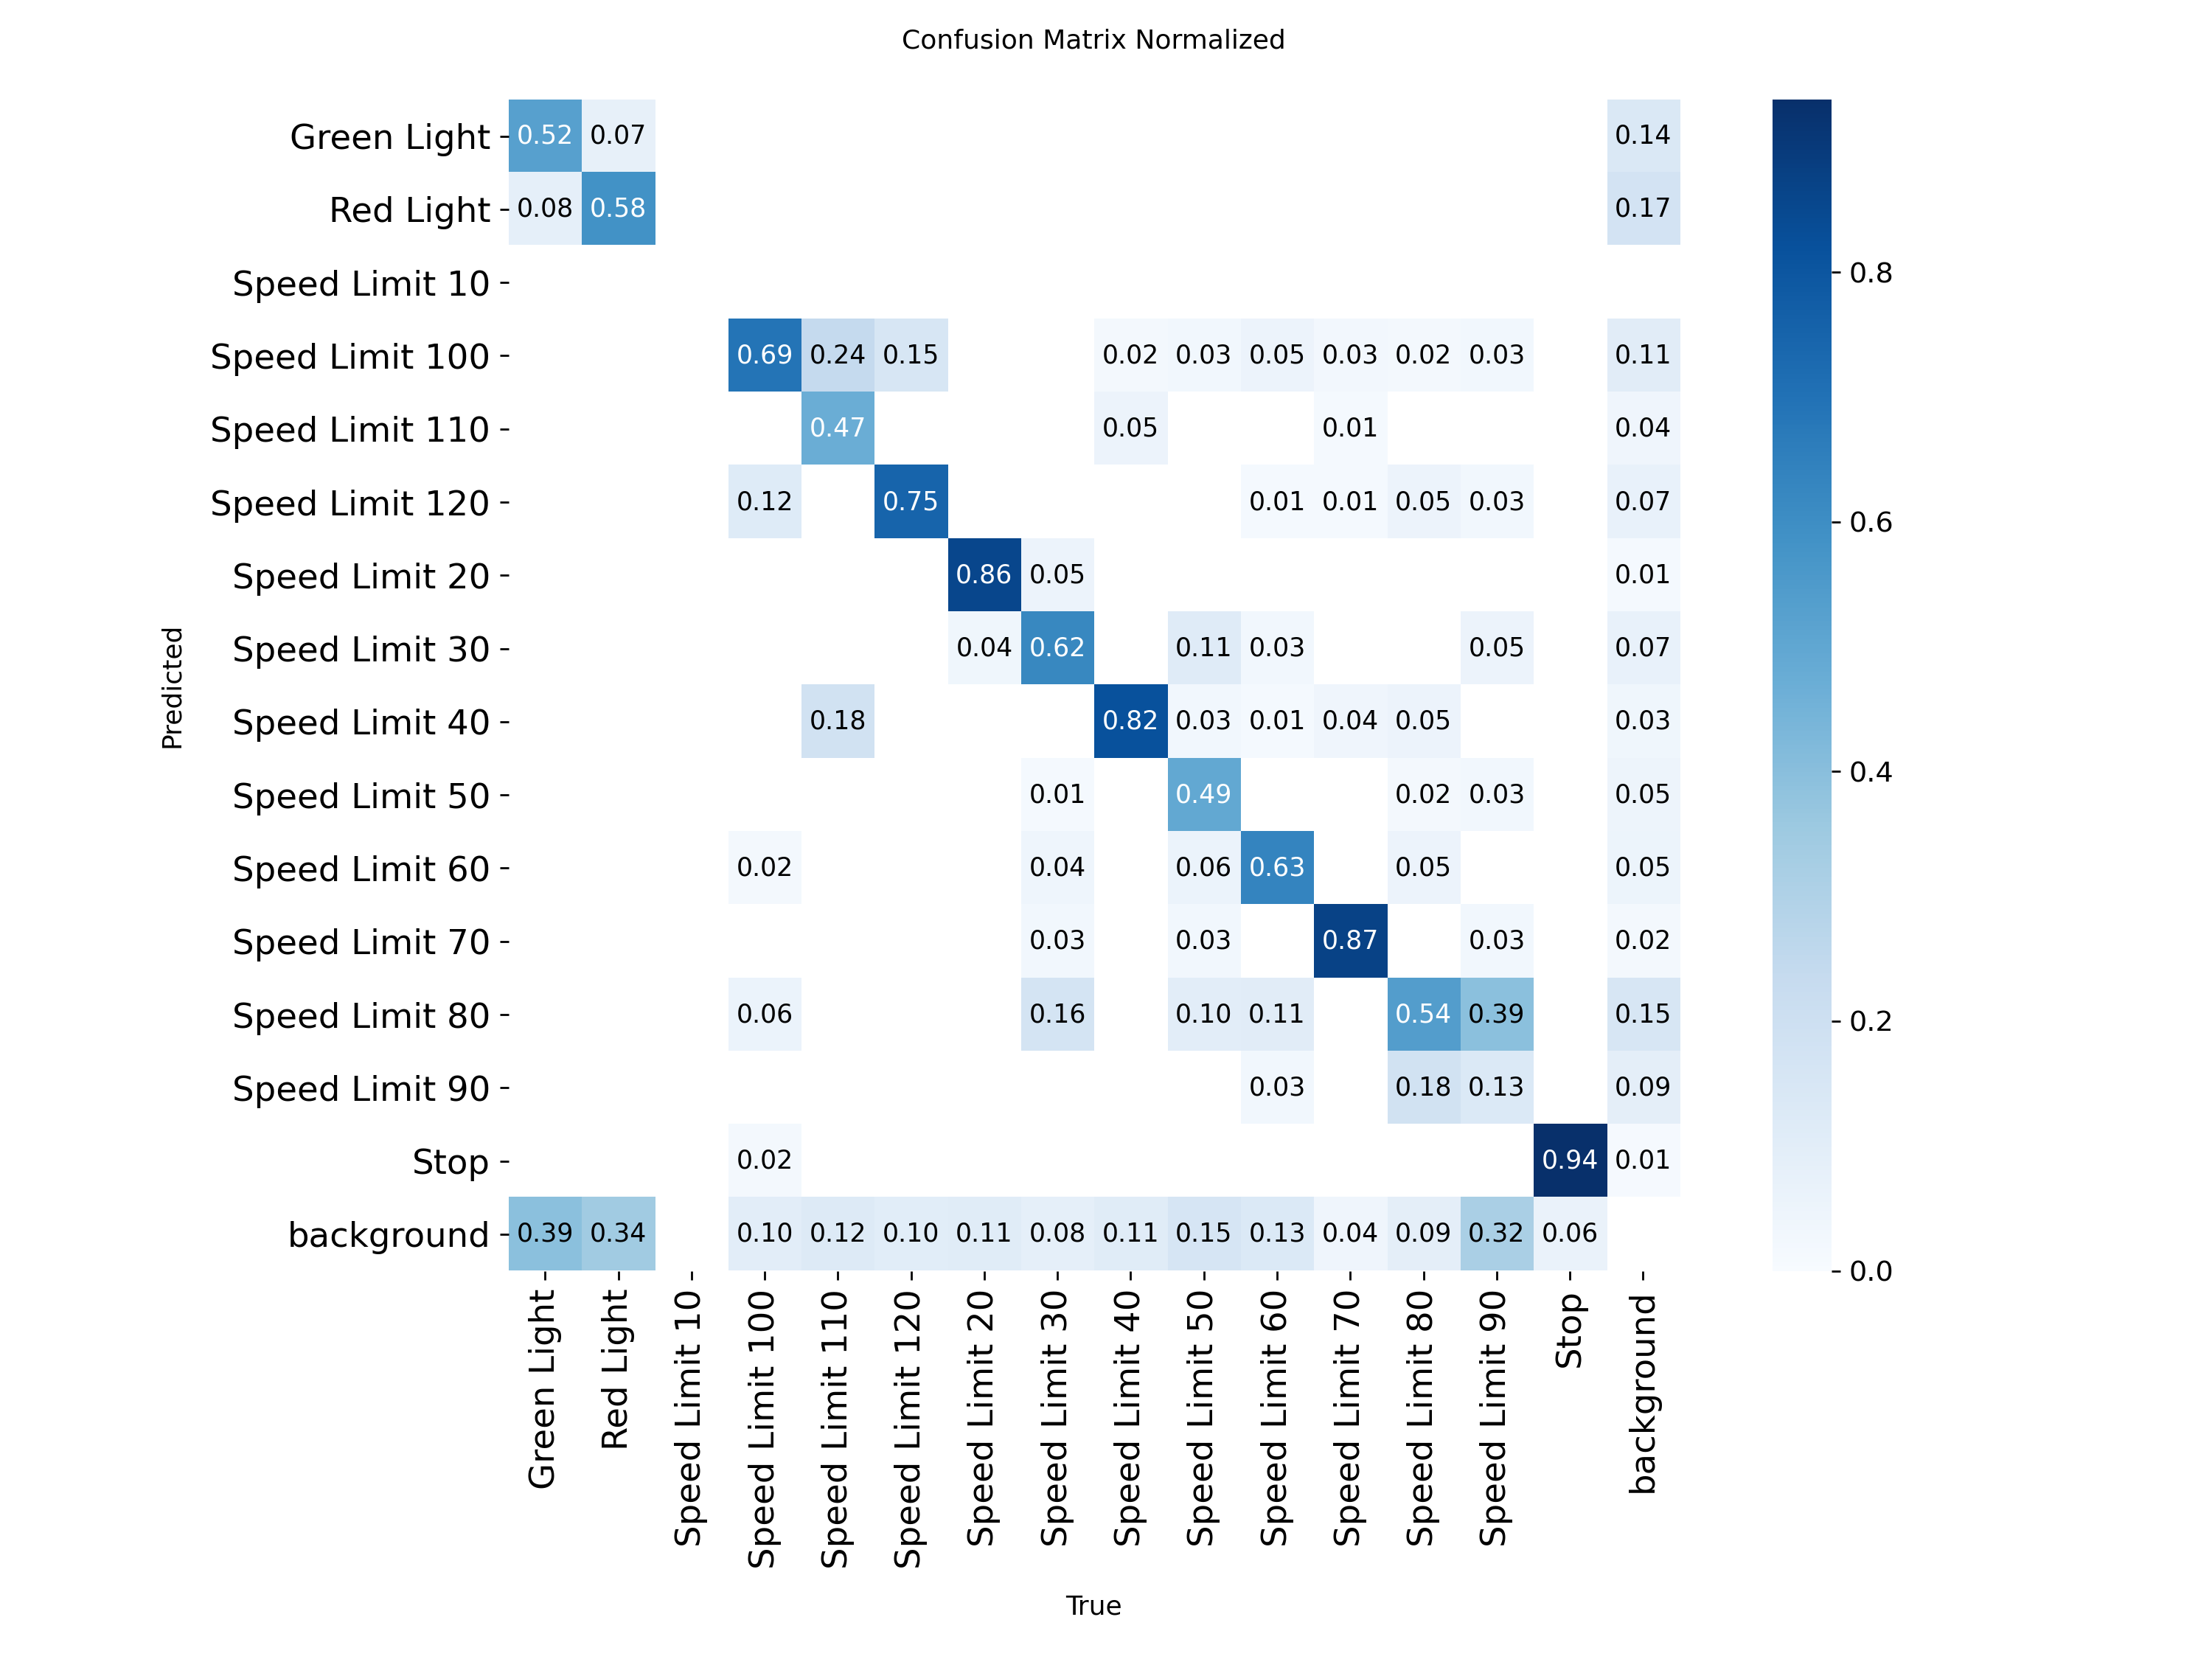

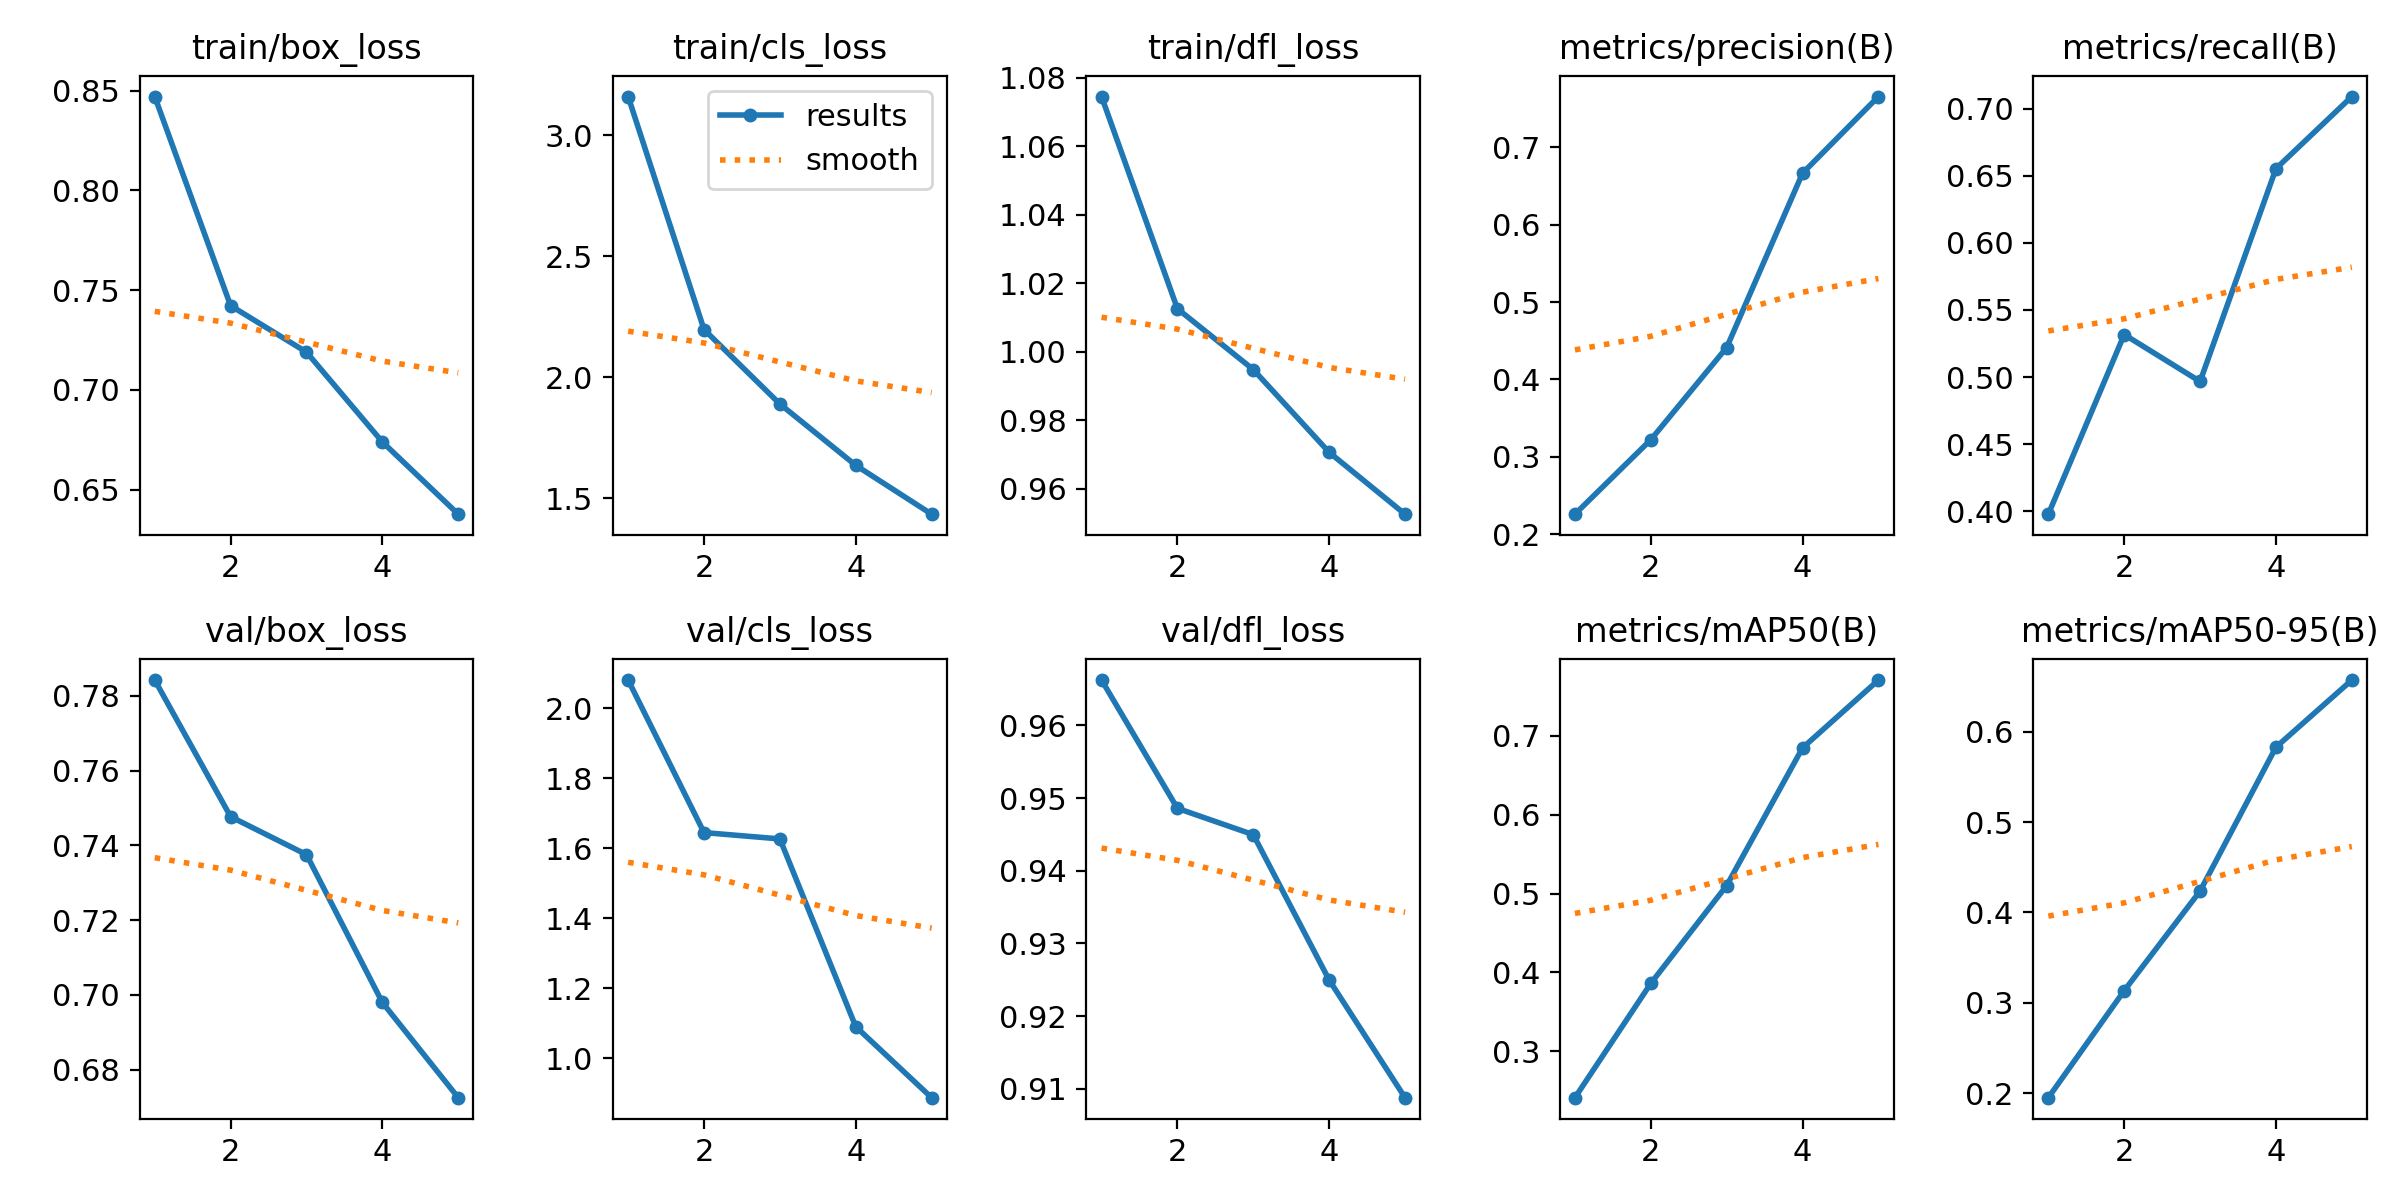

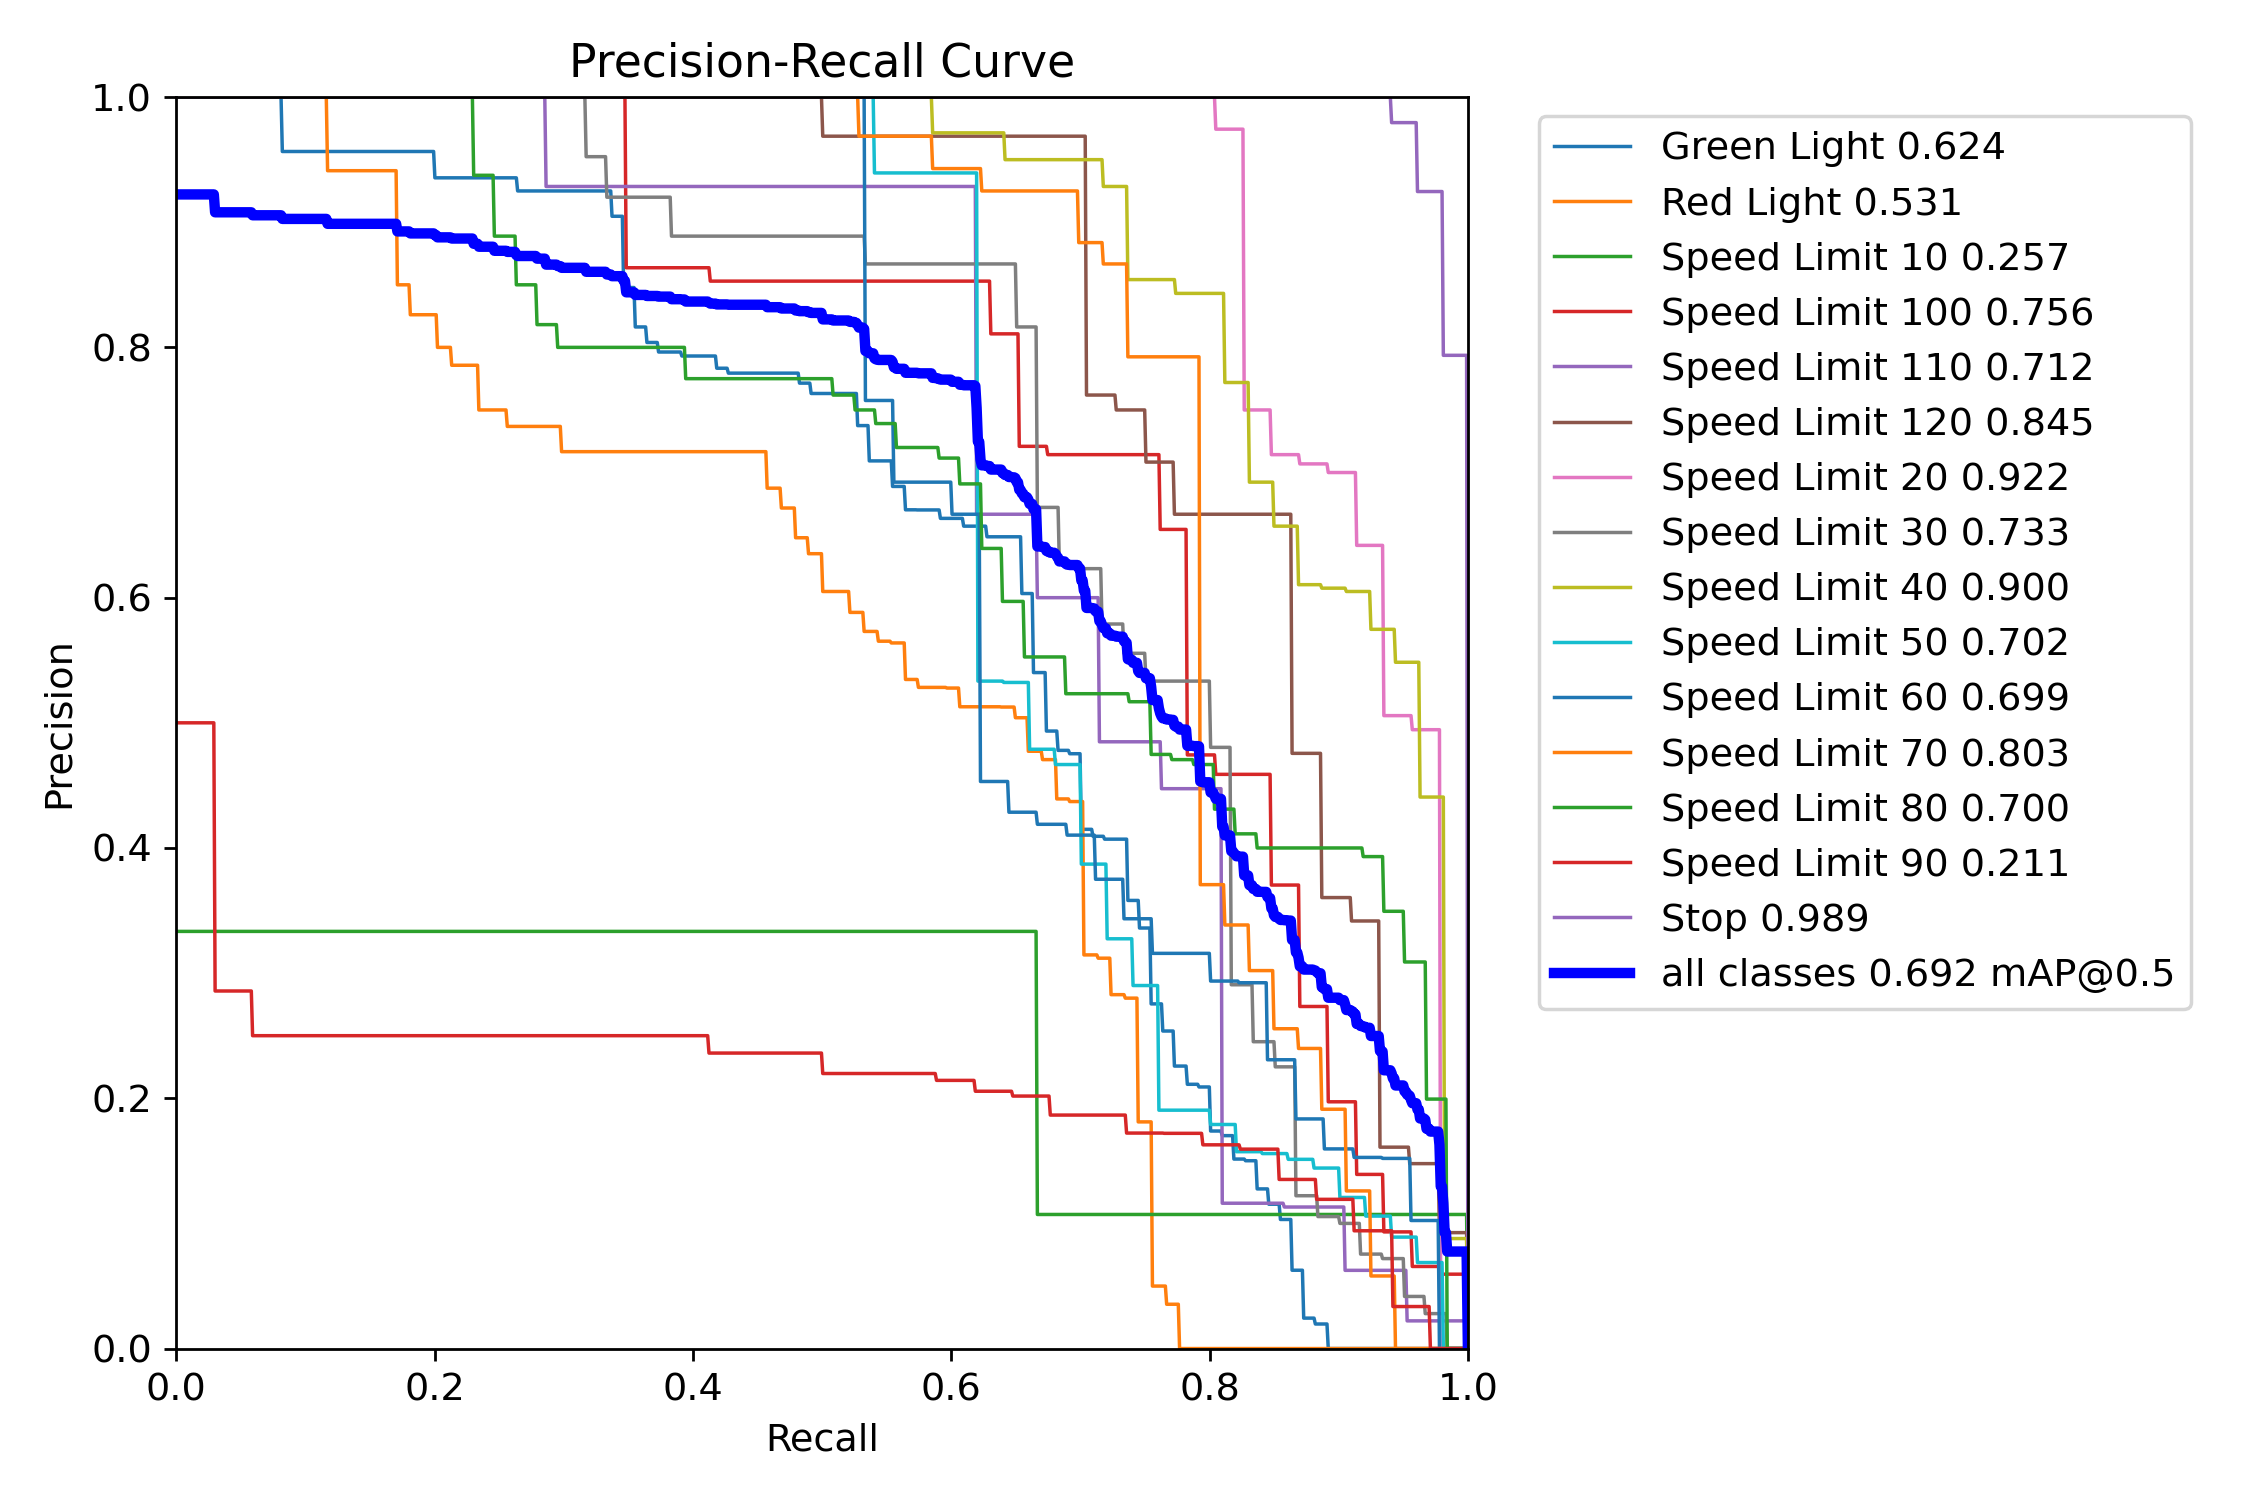

In [9]:
from pathlib import Path

image_dir = "yolov8_traffic_signs"

runs_dir = Path(image_dir)
train_runs = sorted(runs_dir.glob("train_run*"))
val_runs = sorted(runs_dir.glob("val_run*"))

latest_train_run = train_runs[-1] if train_runs else None
latest_val_run = val_runs[-1] if val_runs else None

if latest_train_run:
    train_images = list(latest_train_run.glob("*.png"))
    for img_path in train_images:
        display(Image(filename=str(img_path), width=600))

if latest_val_run:
    pr_curve = latest_val_run / "BoxPR_curve.png"
    if not pr_curve.exists():
        pr_curve = latest_val_run / "PR_curve.png"
    if pr_curve.exists():
        display(Image(filename=str(pr_curve), width=600))
    else:
        print("PR curve image not found.")

In [8]:
test_images = glob.glob("cardetection_dataset/car/test/images/*")

prediction_results = model_ultralytics.predict(
    source=test_images[:5],
    project="yolov8_traffic_signs",
    name="pred_run",
    save=True,
)

pred_runs = sorted(Path("yolov8_traffic_signs").glob("pred_run*"))
latest_pred_run = pred_runs[-1] if pred_runs else None

if latest_pred_run:
    pred_images = list(latest_pred_run.glob("*.jpg"))
    for img_path in pred_images:
        display(Image(filename=str(img_path), width=600))


0: 416x416 1 Speed Limit 30, 3.9ms
1: 416x416 1 Speed Limit 30, 3.9ms
2: 416x416 1 Speed Limit 20, 3.9ms
3: 416x416 1 Speed Limit 20, 3.9ms
4: 416x416 1 Speed Limit 20, 3.9ms
Speed: 0.3ms preprocess, 3.9ms inference, 0.7ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\Panda\Downloads\171\runs\detect\yolov8_traffic_signs\pred_run
